# 3DGS moderno · Mitad 1 — Vistas sintéticas + poses de cámara

**Prerequisito del 3DGS moderno.** El 3DGS entrenado necesita **fotos multi-vista
con pose de cámara conocida** (+ una nube de puntos inicial). No tenemos fotos
dentales reales, pero **sí la malla**: renderizamos N vistas desde ángulos
conocidos → obtenemos **imágenes + poses exactas gratis**, saltándonos COLMAP.

Este notebook **produce el dataset de entrada** para la mitad 2 (entrenamiento con
`gsplat`, notebook siguiente). No usa GPU.

**Qué genera** (en `data/processed/teeth3ds/<caso>_3dgs/`, gitignored):
- `images/r_XXX.png` — N vistas RGB de la malla.
- `transforms.json` — intrínsecos + matriz cámara→mundo (c2w) por vista (formato
  estilo instant-ngp/Nerfstudio).
- `init.ply` — nube de puntos inicial (vértices de la malla) para sembrar el 3DGS.

> **Alcance honesto:** como renderizamos desde la malla, esto valida el **motor
> 3DGS** con verdad-terreno (reconstruir la malla desde sus vistas), no el caso
> «solo fotos reales». Ver [`docs/research/dataset-teeth3ds.md` §5.1](../docs/research/dataset-teeth3ds.md).

## 1 · Carga y configuración

In [1]:
import json
import math
from pathlib import Path

import numpy as np
import vtk
from vtk.util.numpy_support import vtk_to_numpy
from IPython.display import Image, display

vtk.vtkObject.GlobalWarningDisplayOff()

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent
MESH_ROOT = ROOT / "data/raw/teeth3ds/3D_scans_per_patient_obj_files"

PID = sorted(p.name for p in MESH_ROOT.iterdir() if p.is_dir())[0]
JAW = "lower"
W = H = 400                       # resolución de cada vista
VIEW_ANGLE = 30.0                 # FOV vertical (grados)
AZIMUTHS = list(range(0, 360, 30))  # cada 30° -> 12
ELEVATIONS = [15, -25]            # dos anillos -> 24 vistas en total

OUT = ROOT / "data/processed/teeth3ds" / f"{PID}_{JAW}_3dgs"
IMG_DIR = OUT / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

r = vtk.vtkOBJReader()
r.SetFileName(str(MESH_ROOT / PID / f"{PID}_{JAW}.obj"))
r.Update()
poly = r.GetOutput()
pts = vtk_to_numpy(poly.GetPoints().GetData())
print("Caso:", f"{PID}_{JAW}", "·", poly.GetNumberOfPoints(), "vértices")
print("Vistas a generar:", len(AZIMUTHS) * len(ELEVATIONS))

Caso: 01A6GW4A_lower · 109990 vértices
Vistas a generar: 24


## 2 · Poses e intrínsecos

La cámara de VTK (posición, foco, *up*) se convierte a una **matriz cámara→mundo
(c2w)** en convención **OpenGL** (mira a −Z, +Y arriba), que es la que esperan
instant-ngp / Nerfstudio / gsplat. Los **intrínsecos** salen del FOV y el tamaño.

In [2]:
def cam_to_c2w(position, focal, up):
    P = np.asarray(position, float); F = np.asarray(focal, float); U = np.asarray(up, float)
    z = P - F; z /= np.linalg.norm(z)           # +Z hacia atrás
    x = np.cross(U, z); x /= np.linalg.norm(x)  # derecha
    y = np.cross(z, x)                          # arriba
    c2w = np.eye(4)
    c2w[:3, 0] = x; c2w[:3, 1] = y; c2w[:3, 2] = z; c2w[:3, 3] = P
    return c2w


def project_opengl(Xw, c2w, fx, fy, cx, cy):
    Xc = np.linalg.inv(c2w) @ np.array([*Xw, 1.0])
    xc, yc, zc = Xc[:3]
    u = fx * (xc / -zc) + cx
    v = -fy * (yc / -zc) + cy
    return np.array([u, v]), zc


fovy = math.radians(VIEW_ANGLE)
fy = (H / 2) / math.tan(fovy / 2); fx = fy
cx, cy = W / 2, H / 2
print(f"intrínsecos: fx={fx:.1f} fy={fy:.1f} cx={cx} cy={cy}  ({W}x{H}, FOV {VIEW_ANGLE}°)")

intrínsecos: fx=746.4 fy=746.4 cx=200.0 cy=200.0  (400x400, FOV 30.0°)


## 3 · Generar las vistas + `transforms.json`

Órbita de la cámara (azimut × elevación), render offscreen a PNG, y registro de la pose de cada vista. Se **auto-verifica** proyectando un vértice con nuestras poses y comparándolo con lo que dibuja VTK (debe dar ~0 px).

In [3]:
# material tipo diente + luz, para vistas foto-realistas
mapper = vtk.vtkPolyDataMapper(); mapper.SetInputData(poly); mapper.ScalarVisibilityOff()
actor = vtk.vtkActor(); actor.SetMapper(mapper)
actor.GetProperty().SetColor(0.92, 0.87, 0.78); actor.GetProperty().SetSpecular(0.2)

ren = vtk.vtkRenderer(); ren.AddActor(actor); ren.SetBackground(0.05, 0.05, 0.06)
rw = vtk.vtkRenderWindow(); rw.SetOffScreenRendering(1); rw.SetSize(W, H); rw.AddRenderer(ren)
cam = ren.GetActiveCamera(); cam.SetViewAngle(VIEW_ANGLE)
ren.ResetCamera()
base = (cam.GetPosition(), cam.GetFocalPoint(), cam.GetViewUp())

frames, thumbs = [], []
max_reproj_err = 0.0
i = 0
for el in ELEVATIONS:
    for az in AZIMUTHS:
        cam.SetPosition(*base[0]); cam.SetFocalPoint(*base[1]); cam.SetViewUp(*base[2])
        cam.Azimuth(az); cam.Elevation(el); cam.OrthogonalizeViewUp()
        ren.ResetCameraClippingRange(); rw.Render()

        # guardar PNG
        w2i = vtk.vtkWindowToImageFilter(); w2i.SetInput(rw); w2i.Update()
        fname = f"images/r_{i:03d}.png"
        pw = vtk.vtkPNGWriter(); pw.SetFileName(str(OUT / fname)); pw.SetInputConnection(w2i.GetOutputPort()); pw.Write()

        c2w = cam_to_c2w(cam.GetPosition(), cam.GetFocalPoint(), cam.GetViewUp())
        frames.append({"file_path": fname, "transform_matrix": c2w.tolist()})

        # auto-verificación de la pose (reproyección de un vértice vs VTK)
        Xw = pts[0]
        co = vtk.vtkCoordinate(); co.SetCoordinateSystemToWorld(); co.SetValue(*Xw)
        d = np.array(co.GetComputedDoubleDisplayValue(ren)); vtk_pix = np.array([d[0], H - d[1]])
        ours, zc = project_opengl(Xw, c2w, fx, fy, cx, cy)
        if zc < 0:
            max_reproj_err = max(max_reproj_err, float(np.linalg.norm(ours - vtk_pix)))

        if i % 6 == 0:  # unas miniaturas para el montaje
            arr = vtk_to_numpy(w2i.GetOutput().GetPointData().GetScalars())
            thumbs.append(arr.reshape(H, W, -1)[::-1])
        i += 1

transforms = {
    "camera_angle_x": 2 * math.atan((W / 2) / fx),
    "fl_x": fx, "fl_y": fy, "cx": cx, "cy": cy, "w": W, "h": H,
    "frames": frames,
}
(OUT / "transforms.json").write_text(json.dumps(transforms, indent=2))
print(f"generadas {len(frames)} vistas -> {OUT.relative_to(ROOT)}")
print(f"transforms.json escrito ({len(frames)} frames)")
print(f"error máx. de reproyección de las poses: {max_reproj_err:.4f} px",
      "OK" if max_reproj_err < 1.0 else "REVISAR")

generadas 24 vistas -> data/processed/teeth3ds/01A6GW4A_lower_3dgs
transforms.json escrito (24 frames)
error máx. de reproyección de las poses: 0.0000 px OK


## 4 · Vistazo a las vistas generadas

montaje de 4 vistas (una de cada 6):


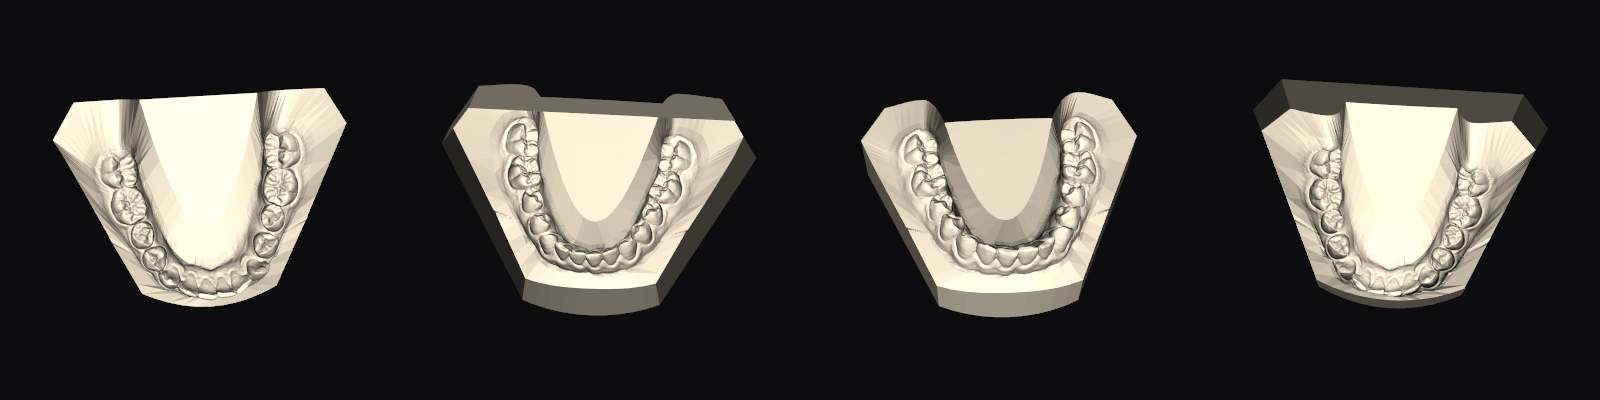

In [4]:
montage = np.concatenate([t[..., :3] for t in thumbs], axis=1)  # fila horizontal
pngmem = vtk.vtkPNGWriter()
# usar PIL-free: volcar con vtk a memoria requiere reconstruir imagedata; más simple, guardar y mostrar
mpath = OUT / "montage.png"
import numpy as _np
from vtk.util.numpy_support import numpy_to_vtk
img = vtk.vtkImageData(); img.SetDimensions(montage.shape[1], montage.shape[0], 1)
flat = montage[::-1].reshape(-1, 3).astype(_np.uint8)
va = numpy_to_vtk(flat, deep=True); va.SetNumberOfComponents(3)
img.GetPointData().SetScalars(va)
pngmem.SetFileName(str(mpath)); pngmem.SetInputData(img); pngmem.Write()
print("montaje de", len(thumbs), "vistas (una de cada 6):")
display(Image(filename=str(mpath)))

## 5 · Nube de puntos inicial (`init.ply`)

Semilla desde la que el 3DGS empieza a optimizar gaussianas. Submuestreamos los vértices de la malla.

In [5]:
cloud = vtk.vtkPolyData(); cloud.SetPoints(poly.GetPoints())
# submuestreo simple para no arrancar con demasiados puntos
mask = vtk.vtkMaskPoints(); mask.SetInputData(cloud); mask.SetOnRatio(3); mask.RandomModeOff(); mask.Update()
ply = vtk.vtkPLYWriter(); ply.SetFileName(str(OUT / "init.ply")); ply.SetInputConnection(mask.GetOutputPort()); ply.Write()
print("init.ply:", mask.GetOutput().GetNumberOfPoints(), "puntos ->", (OUT / "init.ply").relative_to(ROOT))

init.ply: 36664 puntos -> data/processed/teeth3ds/01A6GW4A_lower_3dgs/init.ply


## 6 · Qué hemos producido y qué sigue

**Producido** (en `data/processed/teeth3ds/<caso>_3dgs/`): las **vistas RGB**, las
**poses de cámara** (`transforms.json`, verificadas a ~0 px) y la **nube inicial**
(`init.ply`). Ese es exactamente el paquete de entrada del **3DGS moderno**.

**Siguiente — Mitad 2 (entrenamiento, requiere GPU):**
1. Instalar `torch` (build para Blackwell/sm_120: CUDA 12.8+) y **`gsplat`**.
2. Cargar `transforms.json` + `init.ply`, optimizar las gaussianas contra las
   vistas (pérdida fotométrica) con densificación/poda.
3. Exportar el `.splat`/`.ply` entrenado → serializar al contrato (`TwinSnapshot`)
   y visualizarlo (Issue 3, three.js/GaussianSplats3D).
4. **Métrica gratis:** comparar el 3DGS reconstruido contra la malla original.